In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Import delle tue classi (assumendo che siano accessibili nel path o installate come package)
from data_handler.data_loader import load_cup, normalize, denormalize
from nn.model import Model
from nn.layers import Dense
from nn.activations import Tanh, Identity, ReLU
from nn.losses import MSE
from nn.optim import SGDMomentum, Adam
from nn.metrics import MEE
from nn.callbacks import EarlyStopping
from training.kfold_cv import kfold_cross_validation
from training.trainer import Trainer
from training.model_factory import build_model_from_cfg
import json
import os

# --- 1. CARICAMENTO DELLA CONFIGURAZIONE MIGLIORE ---
# Percorso del file generato dallo step precedente

with open('experiments/CUP/results/cup_exp_1/best_config.json', 'r') as f:
    config = json.load(f)

print("--- Configurazione Originale (Best) ---")
config
# print(json.dumps(config, indent=2)) # Decommenta per vedere tutto

--- Configurazione Originale (Best) ---


{'callbacks': {'early_stopping': True,
  'min_delta': '1e-5',
  'mode': 'min',
  'monitor': 'val_loss',
  'patience': 50,
  'restore_best_weights': True,
  'verbose': 0},
 'cv': {'k': 5, 'seed': 42, 'shuffle': True},
 'data': {'inputs': 12,
  'normalize': True,
  'normalize_target': True,
  'targets': 4,
  'train_path': 'data/CUP/internal_train_80.csv'},
 'model': {'activation': 'tanh',
  'dropout': 0.0,
  'hidden_units': [64, 32, 16],
  'output_activation': 'linear'},
 'optim': {'lr': 0.01, 'momentum': 0.8, 'name': 'sgd'},
 'regularizer': {'l2': 0.0001},
 'seed': 42,
 'split': {'stratified': False, 'val_size': 0.2},
 'training': {'batch_size': 360,
  'epochs': 1000,
  'include_reg_in_val': False,
  'loss': 'mee',
  'metric': 'mee',
  'shuffle': True}}

In [15]:
# --- CONFIGURAZIONE ---
INT_TRAIN = 'data/CUP/internal_train_90.csv'
INT_TEST = 'data/CUP/internal_test_10.csv'

# --- 3. CARICAMENTO E NORMALIZZAZIONE DATI ---
X_train_raw, y_train_raw = load_cup(INT_TRAIN)
X_test_raw, y_test_raw = load_cup(INT_TEST)

# Normalizza gli Input (fondamentale)
X_train, mean_x, std_x = normalize(X_train_raw)
# Usa media e std del training set per normalizzare il test set
X_test, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x) 

# Opzionale: Normalizza gli Output (consigliato per Regressione CUP)
y_train, mean_y, std_y = normalize(y_train_raw)
y_test, _, _ = normalize(y_test_raw, mean=mean_y, std=std_y)

in_dim = X_train.shape[1]
out_dim = y_train.shape[1]

# --- 4. COSTRUZIONE DEL MODELLO ---
# Usiamo la funzione corretta presente nel tuo model_factory.py
print("Costruzione modello in corso...")
model = build_model_from_cfg(
    run_cfg=config,
    seed=42,                # O un seed a tua scelta
    in_dim=in_dim,
    out_dim=out_dim,
    task='regression'       # FONDAMENTALE per il CUP (attiva Identity + MSE)
)

print("Modello creato correttamente.")

# --- 4. ISTANZIAZIONE TRAINER ---
# CORREZIONE: Passiamo solo il modello e il flag verbose
trainer = Trainer(model=model, verbose=True)
print("\nTrainer istanziato correttamente.")

# Parametri per la CV
K_FOLDS = 5
EPOCHS = config['training']['epochs'] # O un numero alto, tanto c'è Early Stopping
BATCH_SIZE = config['training']['batch_size']

print(f"Avvio {K_FOLDS}-Fold CV con normalizzazione interna...")

# Esecuzione
train_stats, val_stats, histories, fold_results = kfold_cross_validation(
    X=X_train_raw,
    y=y_train_raw,
    model=model,
    trainer=trainer,
    k=K_FOLDS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    verbose=1,                 # Vedrai i progressi dei fold
    include_reg_in_val=True,   # Include la regolarizzazione nella val loss
    normalize_data=True,       # ATTIVA normalizzazione input per fold
    normalize_target=True      # ATTIVA normalizzazione target per fold
)

print("\nCross Validation completata.")

Costruzione modello in corso...
Modello creato correttamente.

Trainer istanziato correttamente.
Avvio 5-Fold CV con normalizzazione interna...
Task: Regression (y.shape=(450, 4))
Using KFold with k=5

Fold 1/5
------------------------------------------------------------

      _____     ___                 _ _ _ 
      \_   \   / __\__ ___   ____ _| | (_)
       / /\/  / /  / _` \ \ / / _` | | | |
    /\/ /_   / /__| (_| |\ V / (_| | | | |
    \____/   \____/\__,_| \_/ \__,_|_|_|_|
        
Epoch 3/1000 [>.............................] loss: 4.7026 MEE: 2.0257 val_loss: 3.8764 val_MEE: 1.8435

Epoch 1000/1000 [==============================>] loss: 1.2124 MEE: 0.9792 val_loss: 1.5850 val_MEE: 1.1541
  Train: loss=1.2118, MEE=0.9790
  Val:   loss=1.5850, MEE=1.1541

Fold 2/5
------------------------------------------------------------
Epoch 63/1000 [=>............................] loss: 2.5874 MEE: 1.4815 val_loss: 2.8626 val_MEE: 1.5636
  Train: loss=2.7460, MEE=1.5411
  Val:   loss=2.8268, MEE=1.5574

Fold 3/5
------------------------------------------------------------
Epoch 1000/1000 [==============================>] loss: 1.1833 MEE: 0.9869 val_loss: 1.7267 val_MEE: 1.1375
  Train: loss=1.1828, MEE=0.9867
  Val:   loss=1.7267, MEE=1.1375

Fold 4/5
------------------------------------------------------------
Epoch 648/1000 [===================>..........] loss: 1.3662 MEE: 1.0483 val_loss: 2.0285 val_MEE: 1.3000
  Train: loss=1.4089, MEE=1.0647
  Val:   loss=2.0262, MEE=1.3015

Fold 5/5
------------------------------------------------------------
Epoch 1000/1000 [========

In [16]:
best_epochs = []
best_val_losses = []

print("\n--- Analisi Migliori Epoche per Fold ---")

for i, history in enumerate(histories):
    # CORREZIONE: Usiamo .logs invece di .history
    val_loss_history = history.logs['val_loss'] 
    
    # Troviamo l'indice del valore minimo
    best_epoch_idx = np.argmin(val_loss_history)
    best_epoch = best_epoch_idx + 1
    min_val_loss = val_loss_history[best_epoch_idx]
    
    best_epochs.append(best_epoch)
    best_val_losses.append(min_val_loss)
    
    print(f"Fold {i+1}: Best Epoch = {best_epoch}, Val Loss = {min_val_loss:.6f}")

avg_best_epoch = int(np.mean(best_epochs))
avg_val_loss = np.mean(best_val_losses)

print("-" * 30)
print(f"Media Best Epoch: {avg_best_epoch}")
print(f"Media Best Val Loss: {avg_val_loss:.6f}")


--- Analisi Migliori Epoche per Fold ---
Fold 1: Best Epoch = 1000, Val Loss = 1.584971
Fold 2: Best Epoch = 13, Val Loss = 2.826760
Fold 3: Best Epoch = 1000, Val Loss = 1.726693
Fold 4: Best Epoch = 600, Val Loss = 2.026211
Fold 5: Best Epoch = 991, Val Loss = 1.750308
------------------------------
Media Best Epoch: 720
Media Best Val Loss: 1.982989


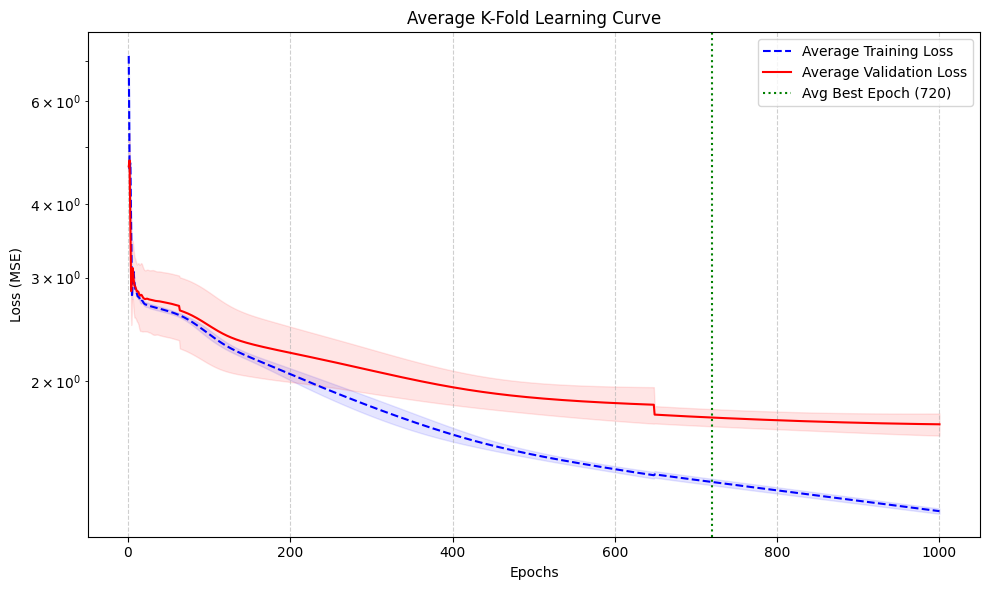

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Aggregazione dei Dati ---
# Determiniamo la lunghezza massima (numero di epoche) raggiunta
max_epochs = max([len(h.logs['loss']) for h in histories])

# Creiamo matrici piene di NaN: shape (n_folds, max_epochs)
all_train_loss = np.full((len(histories), max_epochs), np.nan)
all_val_loss = np.full((len(histories), max_epochs), np.nan)

# Riempiamo le matrici con i dati disponibili
for i, h in enumerate(histories):
    loss = h.logs['loss']
    val_loss = h.logs['val_loss']
    
    # Copiamo i valori fino alla lunghezza di questo fold
    all_train_loss[i, :len(loss)] = loss
    all_val_loss[i, :len(val_loss)] = val_loss

# --- 2. Calcolo Statistiche (Media e Std) ---
# Usiamo nanmean/nanstd per ignorare i valori mancanti (dove i fold erano già finiti)
mean_train_loss = np.nanmean(all_train_loss, axis=0)
std_train_loss = np.nanstd(all_train_loss, axis=0)

mean_val_loss = np.nanmean(all_val_loss, axis=0)
std_val_loss = np.nanstd(all_val_loss, axis=0)

# Calcolo epoca media di stop (per la linea verticale)
avg_best_epoch = int(np.mean(best_epochs))

# --- 3. Plotting ---
plt.figure(figsize=(10, 6))
epochs_range = range(1, max_epochs + 1)

# Plot Training
plt.plot(epochs_range, mean_train_loss, label='Average Training Loss', color='blue', linestyle='--')
plt.fill_between(epochs_range, 
                 mean_train_loss - std_train_loss, 
                 mean_train_loss + std_train_loss, 
                 color='blue', alpha=0.1)

# Plot Validation
plt.plot(epochs_range, mean_val_loss, label='Average Validation Loss', color='red')
plt.fill_between(epochs_range, 
                 mean_val_loss - std_val_loss, 
                 mean_val_loss + std_val_loss, 
                 color='red', alpha=0.1)

# Linea verticale per la "best epoch" media
plt.axvline(x=avg_best_epoch, color='green', linestyle=':', label=f'Avg Best Epoch ({avg_best_epoch})')

plt.title('Average K-Fold Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log') # Consigliato per vedere meglio la convergenza
plt.tight_layout()
plt.show()

In [18]:
import numpy as np
from data_handler.data_loader import normalize, denormalize

# --- 1. ADDESTRAMENTO FINALE (Se non già fatto) ---
# Prima di testare sul 10%, addestriamo il modello su TUTTO il 90% 
# usando la 'avg_best_epoch' trovata con la Cross Validation.

print(f"Addestramento finale su tutto l'internal train (90%) per {avg_best_epoch} epoche...")

# Usiamo i dati caricati e normalizzati all'inizio (X_train, y_train dal 90%)
model.reset()
trainer.fit(
    X_train=X_train, 
    y_train=y_train,
    epochs=avg_best_epoch, # Usiamo la media della Cross Validation
    batch_size=config['training']['batch_size'],
    # verbose=0
)

# --- 2. PREPARAZIONE DATI DI TEST (10%) ---
# X_test_raw e y_test_raw sono i dati mai visti dal modello.
# Fondamentale: usiamo mean/std del TRAINING per normalizzare il TEST.
X_test_norm, _, _ = normalize(X_test_raw, mean=mean_x, std=std_x)

# --- 3. PREDIZIONE E DENORMALIZZAZIONE ---
# Il modello produce output normalizzati
y_pred_norm = model.predict_proba(X_test_norm)

# Riportiamo le predizioni alla scala originale del CUP
# Usiamo mean_y e std_y calcolati sul set di training (90%)
y_pred_orig = denormalize(y_pred_norm, mean=mean_y, std=std_y)

# --- 4. CALCOLO MEE FINALE ---
# Calcolo della distanza euclidea per ogni record rispetto ai target reali (raw)
# Formula: sqrt(sum((y_pred - y_true)^2))
errors = np.linalg.norm(y_pred_orig - y_test_raw, axis=1)

# Media degli errori euclidei
final_mee_test = np.mean(errors)

print("\n" + "="*40)
print(f"RISULTATO FINALE SULL'INTERNAL TEST SET")
print(f"MEE (Original Scale): {final_mee_test:.4f}")
print("="*40)

# Opzionale: Visualizzazione di alcuni esempi
print("\nConfronto prime 5 predizioni (Originale vs Predetto):")
for i in range(5):
    print(f"True: {y_test_raw[i]} -> Pred: {y_pred_orig[i].round(4)}")

Addestramento finale su tutto l'internal train (90%) per 720 epoche...
Epoch 5/720 [>.............................] loss: 2.9280 MEE: 1.5903

Epoch 720/720 [==============================>] loss: 1.1671 MEE: 0.9645

RISULTATO FINALE SULL'INTERNAL TEST SET
MEE (Original Scale): 22.4686

Confronto prime 5 predizioni (Originale vs Predetto):
True: [ 5.631505  2.682506  9.497731 -1.920418] -> Pred: [ 3.1181  6.0447  6.8902 -7.355 ]
True: [ 1.1106811e+01 -1.7356526e+01  1.5164000e-02 -3.7704000e+01] -> Pred: [  2.2212 -11.9308  12.7294 -25.4661]
True: [ 19.880706 -13.118625   6.06071  -37.539524] -> Pred: [ 19.6658  -4.3276  20.6151 -19.3639]
True: [  9.440211 -24.41975  -24.661835  23.262059] -> Pred: [ 26.0595 -29.6488  -3.7754  46.2223]
True: [ -6.146597  -9.796176 -11.355338   9.813975] -> Pred: [ -1.6063  -1.0062 -13.4191   1.293 ]


Caricamento dati da: data/CUP/internal_train_90.csv
Avvio 5-Fold CV per 1000 epoche...
Fold 1/5... 

Done.
Fold 2/5... Done.
Fold 3/5... Done.
Fold 4/5... Done.
Fold 5/5... Done.

=== RISULTATI CROSS VALIDATION ===
Best Epoch (sulla media Val Loss): 1000
MSE a ep.1000: 1.77518 (Scaled)
MEE stimato a ep.1000: 22.12417 (Real Scale)


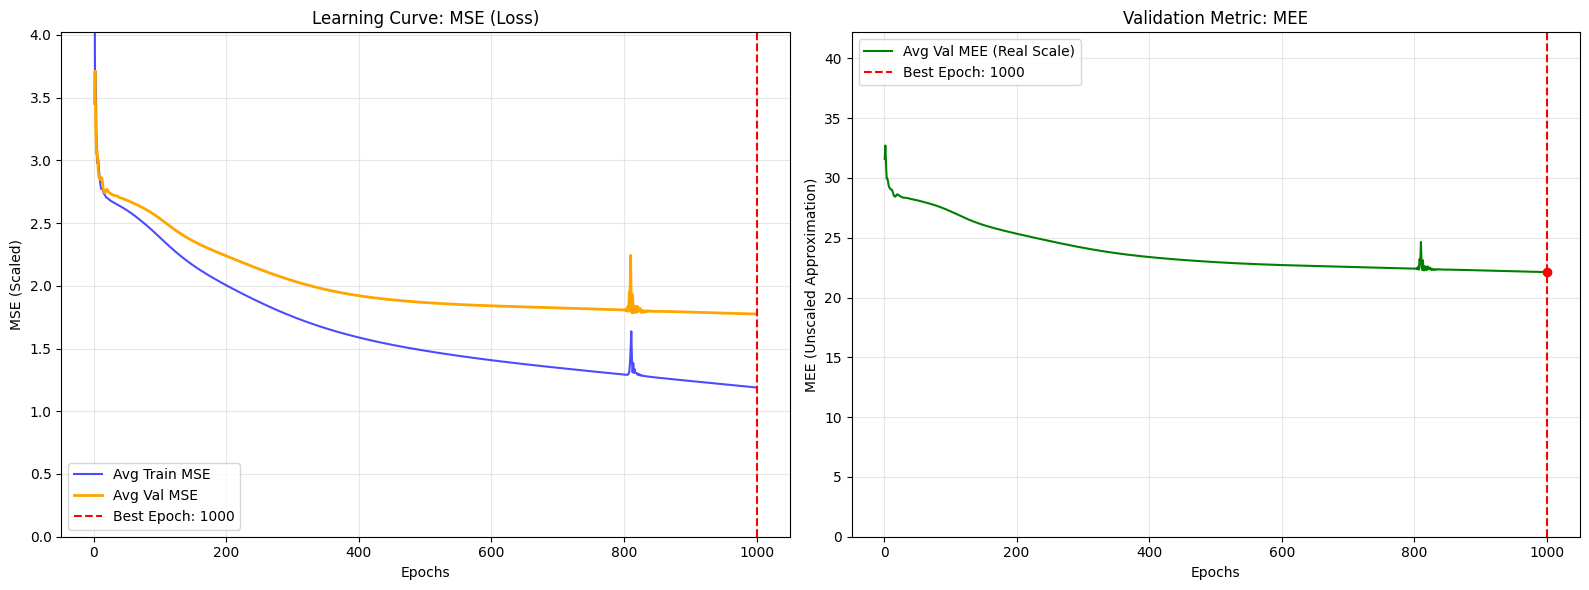

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from experiments.CUP import common
from training.trainer import Trainer  # <--- Import necessario
import copy

# === SETUP ===
# Recuperiamo la config modificata (Assicurati di aver eseguito la cella precedente!)
cv_config = copy.deepcopy(config)

# FORZIAMO I PARAMETRI RICHIESTI
cv_config['training']['epochs'] = 1000          
cv_config['callbacks']['early_stopping'] = False 
cv_config['training']['loss'] = 'mse'            
cv_config['training']['metric'] = 'mee'          
# FORZATURA FONDAMENTALE
cv_config['data']['train_path'] = 'data/CUP/internal_train_90.csv' # O la variabile INT_TRAIN

train_path = cv_config['data']['train_path']
print(f"Caricamento dati da: {train_path}")
X, y = common.load_cup(train_path, training=True)

# === K-FOLD CROSS VALIDATION ===
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

all_train_loss = []
all_val_loss = []
all_val_mee = []

print(f"Avvio {K}-Fold CV per {cv_config['training']['epochs']} epoche...")

for fold_idx, (train_index, val_index) in enumerate(kf.split(X)):
    print(f"Fold {fold_idx+1}/{K}...", end=" ")
    
    # 1. Split Dati
    X_train_f, X_val_f = X[train_index], X[val_index]
    y_train_f, y_val_f = y[train_index], y[val_index]
    
    # 2. Normalizzazione
    scaler_x = StandardScaler()
    X_train_f = scaler_x.fit_transform(X_train_f)
    X_val_f = scaler_x.transform(X_val_f)
    
    scaler_y = StandardScaler()
    y_train_f = scaler_y.fit_transform(y_train_f)
    y_val_f = scaler_y.transform(y_val_f)
    
    # Disabilita normalizzazione interna
    cv_config['data']['normalize'] = False
    cv_config['data']['normalize_target'] = False
    
    # 3. Build Modello
    model = common.build_model(cv_config, seed=42+fold_idx)
    
    # 4. Inizializza Trainer e Addestra (CORREZIONE QUI)
    trainer = Trainer(model, verbose=0)  # verbose=0 per silenziare il training
    
    history = trainer.fit(
        X_train=X_train_f,
        y_train=y_train_f,
        X_val=X_val_f,      # Passati separatamente
        y_val=y_val_f,      # Passati separatamente
        epochs=cv_config['training']['epochs'],
        batch_size=cv_config['training']['batch_size'],
        # validation_data=(...) RIMOSSO perché non supportato
    )
    
    # Recuperiamo le metriche
    # history.history contiene il dizionario dei log
    h = history.history if hasattr(history, 'history') else history.to_dict()
    
    all_train_loss.append(h['loss'])
    all_val_loss.append(h['val_loss'])
    
    # Gestione MEE (riscalata)
    y_std_mean = np.mean(np.sqrt(scaler_y.var_))
    # Il nome della metrica nei log è solitamente minuscolo (es. 'mse', 'mee')
    # Cerchiamo 'val_mee' o 'val_metric'
    metric_key = 'val_mee' if 'val_mee' in h else 'val_metric' 
    # Fallback se non trova keys specifiche (usa l'ultima disponibile se diversa da loss)
    if metric_key not in h:
         # cerca chiavi che iniziano con val_ e non sono val_loss
         candidates = [k for k in h.keys() if k.startswith('val_') and k != 'val_loss']
         if candidates: metric_key = candidates[0]

    val_mee_scaled = np.array(h.get(metric_key, [0]*len(h['loss'])))
    all_val_mee.append(val_mee_scaled * y_std_mean)
    
    print("Done.")

# === AGGREGAZIONE E PLOT (Invariato) ===
avg_train_loss = np.mean(all_train_loss, axis=0)
avg_val_loss = np.mean(all_val_loss, axis=0)
avg_val_mee = np.mean(all_val_mee, axis=0)

best_epoch_idx = np.argmin(avg_val_loss)
best_epoch = best_epoch_idx + 1 
best_val_loss = avg_val_loss[best_epoch_idx]
best_val_mee = avg_val_mee[best_epoch_idx]

print(f"\n=== RISULTATI CROSS VALIDATION ===")
print(f"Best Epoch (sulla media Val Loss): {best_epoch}")
print(f"MSE a ep.{best_epoch}: {best_val_loss:.5f} (Scaled)")
print(f"MEE stimato a ep.{best_epoch}: {best_val_mee:.5f} (Real Scale)")

epochs_range = range(1, len(avg_train_loss) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss
ax1.plot(epochs_range, avg_train_loss, label='Avg Train MSE', color='blue', alpha=0.7)
ax1.plot(epochs_range, avg_val_loss, label='Avg Val MSE', color='orange', linewidth=2)
ax1.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
ax1.set_title('Learning Curve: MSE (Loss)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE (Scaled)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, np.percentile(avg_val_loss, 95) * 1.5) 

# Plot 2: Metric
ax2.plot(epochs_range, avg_val_mee, label='Avg Val MEE (Real Scale)', color='green')
ax2.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
ax2.scatter(best_epoch, best_val_mee, color='red', zorder=5)
ax2.set_title('Validation Metric: MEE')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MEE (Unscaled Approximation)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, np.percentile(avg_val_mee, 95) * 1.5)

plt.tight_layout()
plt.show()